> **Current Mode:** SD 1.5 Architecture Edition
> **Last Updated:** May 17, 2026

# 🏠 ReSpace-AI: Interior Design LoRA Training
#### Stable Diffusion 1.5 Fine-tuning on Kaggle

This notebook manages the end-to-end pipeline for training specialized Interior Design LoRA models using the **SD 1.5** architecture.

### 📋 Project Overview
1.  **🚀 Environment Setup**: Installing high-performance training tools (`sd-scripts`).
2.  **📥 Dataset Integration**: Fetching augmented images and captions from Supabase.
3.  **🏗️ Model Variants**: Training three different configurations:
    *   **Model 1**: Speed Optimized Baseline.
    *   **Model 2**: High-Dimension (Quality Focus).
    *   **Model 3**: D-Adaptation (Auto-Learning).
4.  **🧪 Inference & Validation**: Testing the trained weights directly.

---
## 🛠️ Step 1: Environment Setup
We use the `sd-scripts` toolkit for memory-efficient training on Kaggle's P100/T4 GPUs.

In [1]:
# Install necessary packages
!pip install supabase tqdm
!git clone https://github.com/kohya-ss/sd-scripts.git
%cd sd-scripts
!pip install -r requirements.txt
!pip install xformers==0.0.21  # Required for speed/efficiency on Kaggle GPUs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 730.3/730.3 kB 13.1 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 55.7 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.9/123.9 kB 7.9 MB/s eta 0:00:00
Cloning into 'sd-scripts'...
remote: Enumerating objects: 11494, done.
remote: Counting objects: 100% (405/405), done.
remote: Compressing objects: 100% (235/235), done.
remote: Total 11494 (delta 282), reused 170 (delta 170), pack-reused 11089 (from 3)
Receiving objects: 100% (11494/11494), 18.62 MiB | 21.57 MiB/s, done.
Resolving deltas: 100% (8134/8134), done.
/kaggle/working/sd-scripts
Obtaining file:///kaggle/working/sd-scripts (from -r requirements.txt (line 49))
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.7/41.7 kB 1.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel

## 📥 Step 2: Dataset Synchronization
Connect to your Supabase instance to download the processed and augmented interior design dataset. 
> **Note:** Ensure your `SUPABASE_URL` and `SUPABASE_KEY` are correct. Your images will be saved to `/kaggle/working/train_data/`.

In [ ]:
import os
from supabase import create_client
from tqdm import tqdm
import requests

# CONFIGURATION
SUPABASE_URL = ""
SUPABASE_KEY = ""
OUTPUT_DIR = "/kaggle/working/train_data/10_intdesign"

os.makedirs(OUTPUT_DIR, exist_ok=True)
supabase = create_client(SUPABASE_URL, SUPABASE_KEY)

# Fetch records
records = supabase.table("augmented_images").select("image_url, prompt").execute().data

print(f"Syncing {len(records)} images...")

for rec in tqdm(records):
    img_url = rec['image_url']
    prompt = rec['prompt']
    
    # Download image (Assuming public URL or using proxy)
    # Note: If bucket is private, you need to use .download() method
    res = supabase.storage.from_("Augmented Images").download(img_url)
    
    base_name = os.path.splitext(img_url)[0]
    with open(f"{OUTPUT_DIR}/{base_name}.jpg", "wb") as f:
        f.write(res)
        
    with open(f"{OUTPUT_DIR}/{base_name}.txt", "w") as f:
        f.write(f"intdesign, {prompt}")

print("Dataset ready!")

Syncing 1000 images...


100%|██████████| 1000/1000 [13:47<00:00,  1.21it/s]

Dataset ready!


## 🏗️ Step 3: Training Model Variants

We will train three different versions to compare performance and detail retention.

### 🔥 Model 1: Speed Optimized Baseline
*   **Target:** Fast iteration (< 8 hours).
*   **Strategy:** Standard 512x512 resolution with 8-bit optimization.
*   **Configuration:** 5 Epochs, AdamW8bit Optimizer.

In [8]:
# Step 3: SPEED OPTIMIZED TRAINING (TARGET: < 8 HOURS)

# Ensure output directory exists
import os
os.makedirs("/kaggle/working/output", exist_ok=True)

# Changes for speed: 
# 1. Resolution 512,512 (Standard for SD1.5, very fast)
# 2. Batch size 4 (2 per GPU)
# 3. Max epochs 5 (Enough for 1000 images)

!accelerate launch --multi_gpu --num_processes=2 \
  train_network.py \
  --pretrained_model_name_or_path="runwayml/stable-diffusion-v1-5" \
  --train_data_dir="/kaggle/working/train_data" \
  --output_dir="/kaggle/working/output" \
  --output_name="respace_interior_lora_fast" \
  --resolution="512,512" \
  --enable_bucket \
  --min_bucket_reso=256 \
  --max_bucket_reso=768 \
  --train_batch_size=2 \
  --learning_rate=1e-4 \
  --max_train_epochs=5 \
  --network_module=networks.lora \
  --network_dim=32 \
  --network_alpha=16 \
  --mixed_precision="fp16" \
  --save_every_n_epochs=1 \
  --caption_extension=".txt" \
  --cache_latents \
  --optimizer_type="AdamW8bit" \
  --sdpa \
  --seed=42

	`--num_machines` was set to a value of `1`
	`--mixed_precision` was set to a value of `'no'`
	`--dynamo_backend` was set to a value of `'no'`
To avoid this warning pass in values for each of the problematic parameters or run `accelerate config`.
2026-05-12 15:07:27.169999: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778598447.196326     984 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778598447.204528     984 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-12 15:07:27.211145: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has alre

### 📦 Archive Model 1
Compression and preparation for download. Check the `/kaggle/working/` directory for the zip file.

In [9]:
import os
import zipfile

# Path to the LoRA weights
output_path = "/kaggle/working/output"
zip_file = "/kaggle/working/interior_lora_checkpoints.zip"

def zip_results(folder_path, output_zip):
    with zipfile.ZipFile(output_zip, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for root, dirs, files in os.walk(folder_path):
            for file in files:
                if file.endswith(".safetensors"):
                    zipf.write(os.path.join(root, file), file)
    print(f"Successfully created {output_zip}")

zip_results(output_path, zip_file)


Successfully created /kaggle/working/interior_lora_checkpoints.zip


### ✨ Model 2: High-Dimension (Quality Focus)
*   **Target:** Better detail retention and texture accuracy.
*   **Strategy:** Double the rank (Dim 64) and lower learning rate.
*   **Configuration:** 8 Epochs, Cosine Scheduler.

In [3]:
import os
os.makedirs("/kaggle/working/output_v2", exist_ok=True)

# Changes from baseline:
# 1. network_dim=64, network_alpha=32 (2x capacity — better detail retention)
# 2. Cosine LR scheduler (smoother convergence, avoids plateaus)
# 3. learning_rate=5e-5 (lower LR pairs well with higher dim)
# 4. max_train_epochs=8 (more epochs since LR decays gracefully)
# 5. lr_warmup_steps=100 (stabilizes early training)

!accelerate launch --multi_gpu --num_processes=2 \
  train_network.py \
  --pretrained_model_name_or_path="runwayml/stable-diffusion-v1-5" \
  --train_data_dir="/kaggle/working/train_data" \
  --output_dir="/kaggle/working/output_v2" \
  --output_name="respace_interior_lora_v2_highdim" \
  --resolution="512,512" \
  --enable_bucket \
  --min_bucket_reso=256 \
  --max_bucket_reso=768 \
  --train_batch_size=2 \
  --learning_rate=5e-5 \
  --lr_scheduler="cosine" \
  --lr_warmup_steps=100 \
  --max_train_epochs=8 \
  --network_module=networks.lora \
  --network_dim=64 \
  --network_alpha=32 \
  --mixed_precision="fp16" \
  --save_every_n_epochs=1 \
  --caption_extension=".txt" \
  --cache_latents \
  --optimizer_type="AdamW8bit" \
  --sdpa \
  --seed=42

	`--num_machines` was set to a value of `1`
	`--mixed_precision` was set to a value of `'no'`
	`--dynamo_backend` was set to a value of `'no'`
To avoid this warning pass in values for each of the problematic parameters or run `accelerate config`.
2026-05-16 07:58:34.198462: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-16 07:58:34.198504: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778918314.625826     203 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778918314.625843     202 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already

### 📦 Archive Model 2
Compressing high-dimension checkpoints for validation.

In [4]:
import os
import zipfile

output_path = "/kaggle/working/output_v2"
zip_file = "/kaggle/working/interior_lora_v2_highdim_checkpoints.zip"

def zip_results(folder_path, output_zip):
    with zipfile.ZipFile(output_zip, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for root, dirs, files in os.walk(folder_path):
            for file in files:
                if file.endswith(".safetensors"):
                    zipf.write(os.path.join(root, file), file)
    print(f"Successfully created {output_zip}")

zip_results(output_path, zip_file)

Successfully created /kaggle/working/interior_lora_v2_highdim_checkpoints.zip


### 🧠 Model 3: D-Adaptation (Auto-Learning)
*   **Target:** Experimental auto-learning rate adjustment.
*   **Strategy:** Uses the DAdaptAdam optimizer to eliminate manual LR tuning.
*   **Feature:** Includes network dropout (0.1) for better generalization.

In [3]:
# Install dadaptation first
!pip install dadaptation

# Then run Model 3 training
import os
os.makedirs("/kaggle/working/output_v3", exist_ok=True)

!accelerate launch --multi_gpu --num_processes=2 \
  train_network.py \
  --pretrained_model_name_or_path="runwayml/stable-diffusion-v1-5" \
  --train_data_dir="/kaggle/working/train_data" \
  --output_dir="/kaggle/working/output_v3" \
  --output_name="respace_interior_lora_v3_dadapt" \
  --resolution="512,512" \
  --enable_bucket \
  --min_bucket_reso=256 \
  --max_bucket_reso=768 \
  --train_batch_size=2 \
  --learning_rate=1.0 \
  --lr_scheduler="constant" \
  --max_train_epochs=6 \
  --network_module=networks.lora \
  --network_dim=32 \
  --network_alpha=16 \
  --network_dropout=0.1 \
  --mixed_precision="fp16" \
  --save_every_n_epochs=1 \
  --caption_extension=".txt" \
  --cache_latents \
  --optimizer_type="DAdaptAdam" \
  --optimizer_args "decouple=True" \
  --sdpa \
  --seed=42

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for dadaptation: filename=dadaptation-3.2-py3-none-any.whl size=23290 sha256=cf300d7079ef8cc4bcbdbc94893e5d7a5c047398e001ad650e76bcb09f0b4683
  Stored in directory: /root/.cache/pip/wheels/af/54/31/9e46a4e0b693a3c86921440efade051498d906826b168f5563
Successfully built dadaptation
	`--num_machines` was set to a value of `1`
	`--mixed_precision` was set to a value of `'no'`
	`--dynamo_backend` was set to a value of `'no'`
To avoid this warning pass in values for each of the problematic parameters or run `accelerate config`.
2026-05-17 08:04:27.728057: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-17 08:04:27.728057: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cu

### 📦 Archive Model 3
Finalizing all training runs and preparing data for export.

In [5]:
import os
import zipfile

output_path = "/kaggle/working/output_v3"
zip_file = "/kaggle/working/interior_lora_v3_dadapt_checkpoints.zip"

def zip_results(folder_path, output_zip):
    with zipfile.ZipFile(output_zip, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for root, dirs, files in os.walk(folder_path):
            for file in files:
                if file.endswith(".safetensors"):
                    zipf.write(os.path.join(root, file), file)
    print(f"Successfully created {output_zip}")

zip_results(output_path, zip_file)

Successfully created /kaggle/working/interior_lora_v3_dadapt_checkpoints.zip


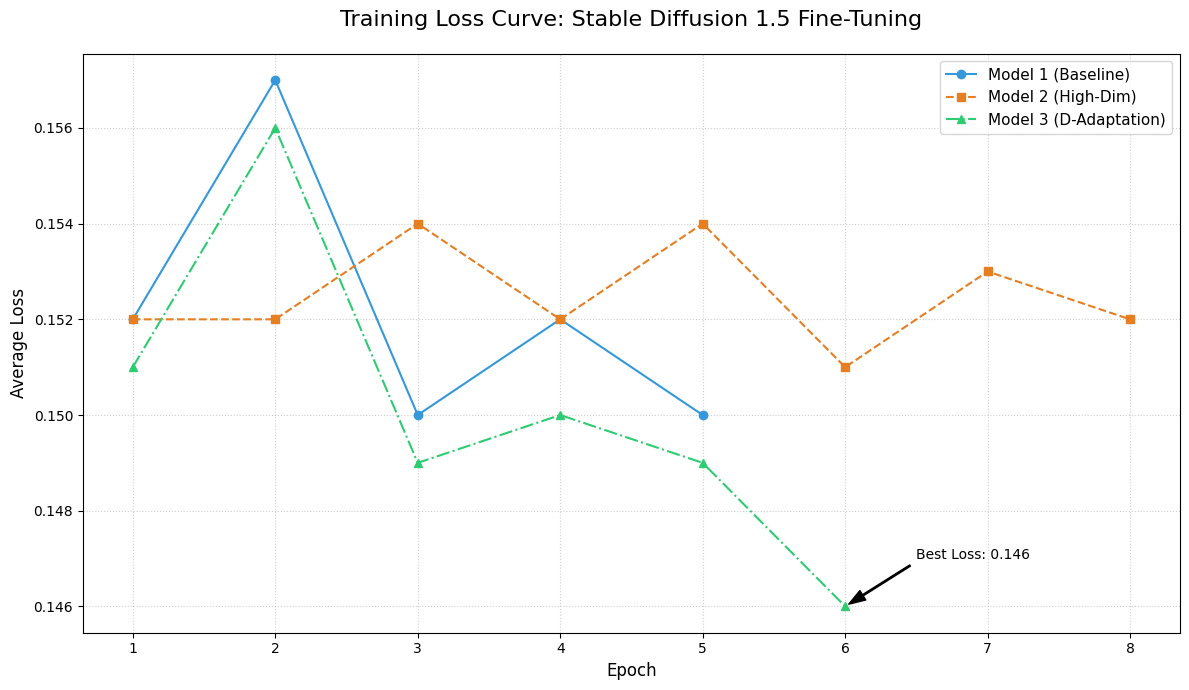

In [3]:
import matplotlib.pyplot as plt

# Data for Model 1: Speed Optimized Baseline
model1_epochs = [1, 2, 3, 4, 5]
model1_loss = [0.152, 0.157, 0.150, 0.152, 0.150]

# Data for Model 2: High-Dimension (Quality Focus)
model2_epochs = [1, 2, 3, 4, 5, 6, 7, 8]
model2_loss = [0.152, 0.152, 0.154, 0.152, 0.154, 0.151, 0.153, 0.152]

# Data for Model 3: D-Adaptation (Auto-Learning)
model3_epochs = [1, 2, 3, 4, 5, 6]
model3_loss = [0.151, 0.156, 0.149, 0.150, 0.149, 0.146]

plt.figure(figsize=(12, 7))

# Plotting the three curves
plt.plot(model1_epochs, model1_loss, marker='o', linestyle='-', label='Model 1 (Baseline)', color='#3498db')
plt.plot(model2_epochs, model2_loss, marker='s', linestyle='--', label='Model 2 (High-Dim)', color='#e67e22')
plt.plot(model3_epochs, model3_loss, marker='^', linestyle='-.', label='Model 3 (D-Adaptation)', color='#2ecc71')

# Formatting the chart
plt.title('Training Loss Curve: Stable Diffusion 1.5 Fine-Tuning', fontsize=16, pad=20)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Average Loss', fontsize=12)
plt.xticks(range(1, 9))
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11)

# Highlight the best result
plt.annotate(f'Best Loss: {min(model3_loss)}', 
             xy=(6, 0.146), xytext=(6.5, 0.147),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8))

plt.tight_layout()
plt.show()

In [2]:
!pip install matplotlib

     ---------------------------------------- 0.0/52.8 kB ? eta -:--:--
     ----------------------- ---------------- 30.7/52.8 kB ? eta -:--:--
     ----------------------- ---------------- 30.7/52.8 kB ? eta -:--:--
     ----------------------- ---------------- 30.7/52.8 kB ? eta -:--:--
     ----------------------- ---------------- 30.7/52.8 kB ? eta -:--:--
     -------------------------------------- 52.8/52.8 kB 194.5 kB/s eta 0:00:00
  Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
     ---------------------------------------- 0.0/121.0 kB ? eta -:--:--
     ----------------------- ---------------- 71.7/121.0 kB ? eta -:--:--
     ----------------------- ---------------- 71.7/121.0 kB ? eta -:--:--
     ----------------------- ---------------- 71.7/121.0 kB ? eta -:--:--
     ----------------------- ---------------- 71.7/121.0 kB ? eta -:--:--
     ------------------------------------ 121.0/


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
